# Итоговая работа по HR.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 1. Загрузка файла HR.csv в pandas DataFrame

In [ ]:
import os

path = '/content/drive/MyDrive/Итоговый проект по курсу/HR.csv'

if os.path.exists(path):
    print("Файл найден:", path)
else:
    print("Файл НЕ найден. Проверьте путь и название папки/файла.")

df = pd.read_csv(path)

Файл найден: /content/drive/MyDrive/Итоговый проект по курсу/HR.csv


In [ ]:
df.columns = df.columns.str.strip()

rename_map = {
    "number_project": "number_projects",
    "average_montly_hours": "average_monthly_hours",
    "Work_accident": "work_accident",
    "sales": "department",
    "Last_evaluation": "last_evaluation",
}
df = df.rename(columns=rename_map)

display(df.head())
print("Размер таблицы:", df.shape)

,satisfaction_level,last_evaluation,number_projects,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


Размер таблицы: (14999, 10)


In [ ]:
print("\nИнформация о данных:")
df.info()


Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_projects        14999 non-null  int64  
 3   average_monthly_hours  14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [ ]:
print("\nПропуски:")
print(df.isna().sum())


Пропуски:
satisfaction_level       0
last_evaluation          0
number_projects          0
average_monthly_hours    0
time_spend_company       0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64


Для анализа был загружен файл `HR.csv` в среду pandas DataFrame. На этапе загрузки выполнены следующие подготовительные операции:

1. **Проверка наличия файла** — подтверждено успешное обнаружение файла по указанному пути.
2. **Нормализация названий колонок** — удалены возможные пробелы, а также выполнено переименование ряда столбцов для приведения к единому стандарту:
   - `number_project` → `number_projects`
   - `average_montly_hours` → `average_monthly_hours` (исправлена опечатка)
   - `Work_accident` → `work_accident`
   - `sales` → `department` (более точное смысловое название)
   - `Last_evaluation` → `last_evaluation`

### Результаты

- **Размер датасета:** 14 999 записей × 10 признаков.
- **Типы данных:** 2 непрерывных (`float64`), 6 целочисленных (`int64`), 2 категориальных (`object`).
- **Пропуски:** **Отсутствуют** во всех колонках — данные полностью заполнены и готовы к анализу.

### Вывод

> **Качество данных: отличное.** Датасет не содержит пропущенных значений, что исключает необходимость в импутации и снижает риск искажения результатов. Объем выборки (почти 15 000 сотрудников) обеспечивает статистическую надежность выводов. Структура данных позволяет проводить как описательный, так и прогнозный анализ.

## 2. Основные статистики для переменных
Считаем среднее, медиану, моду, минимум, максимум и стандартное отклонение.

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

stats_num = df[num_cols].agg(["mean", "median", "min", "max", "std"]).T
stats_num["mode"] = df[num_cols].mode().iloc[0]
stats_num = stats_num[["mean", "median", "mode", "min", "max", "std"]]

display(stats_num)

,mean,median,mode,min,max,std
satisfaction_level,0.612834,0.64,0.10,0.09,1.0,0.248631
last_evaluation,0.716102,0.72,0.55,0.36,1.0,0.171169
number_projects,3.803054,4.00,4.00,2.00,7.0,1.232592
average_monthly_hours,201.050337,200.00,135.00,96.00,310.0,49.943099
time_spend_company,3.498233,3.00,3.00,2.00,10.0,1.460136
work_accident,0.144610,0.00,0.00,0.00,1.0,0.351719
left,0.238083,0.00,0.00,0.00,1.0,0.425924
promotion_last_5years,0.021268,0.00,0.00,0.00,1.0,0.144281


In [ ]:
display(df[cat_cols].describe().T)

for col in cat_cols:
    print(f"{col}: мода = {df[col].mode().iloc[0]}")

,count,unique,top,freq
department,14999,10,sales,4140
salary,14999,3,low,7316


department: мода = sales
salary: мода = low


Для каждой количественной переменной рассчитаны: среднее, медиана, мода, минимум, максимум и стандартное отклонение. Для категориальных — частота и мода.

### Ключевые показатели

| Переменная | Среднее | Медиана | Мода | Мин | Макс | Ст. откл. |
|:---|:---:|:---:|:---:|:---:|:---:|:---:|
| `satisfaction_level` | 0.613 | 0.64 | 0.10 | 0.09 | 1.00 | 0.249 |
| `last_evaluation` | 0.716 | 0.72 | 0.55 | 0.36 | 1.00 | 0.171 |
| `number_projects` | 3.80 | 4.00 | 4.00 | 2.00 | 7.00 | 1.23 |
| `average_monthly_hours` | 201.05 | 200.00 | 135.00 | 96.00 | 310.00 | 49.94 |
| `time_spend_company` | 3.50 | 3.00 | 3.00 | 2.00 | 10.00 | 1.46 |
| `work_accident` | 0.145 | 0.00 | 0.00 | 0.00 | 1.00 | 0.352 |
| `left` | 0.238 | 0.00 | 0.00 | 0.00 | 1.00 | 0.426 |
| `promotion_last_5years` | 0.021 | 0.00 | 0.00 | 0.00 | 1.00 | 0.144 |

**Категориальные переменные:**
- `department`: 10 уникальных значений, мода — **`sales`** (4140 сотрудников).
- `salary`: 3 уникальных значения, мода — **`low`** (7316 сотрудников).

### Интерпретация и выводы для руководства

1. **Удовлетворенность (`satisfaction_level`):**
   - Медиана (0.64) **выше среднего** (0.613), а мода составляет всего **0.10** — это свидетельствует о **левом смещении распределения**: значительная группа сотрудников демонстрирует крайне низкую удовлетворенность, которая «тянет» среднее вниз. Это тревожный сигнал.

2. **Оценка эффективности (`last_evaluation`):**
   - Средняя оценка 0.716 при медиане 0.72 — распределение близко к симметричному. Общая производительность персонала оценивается как **достаточно высокая**.

3. **Рабочая нагрузка (`average_monthly_hours`):**
   - Средняя нагрузка **201 час/месяц** при стандартной норме ~160–170 часов. Это указывает на **систематическую переработку** в компании. Разброс (ст. откл. ~50 часов) также велик, что говорит о неравномерном распределении нагрузки.

4. **Текучесть (`left`):**
   - **23.8% сотрудников уволились** — почти каждый четвертый. Это **высокий уровень текучести**, требующий немедленного внимания со стороны HR-департамента.

5. **Повышения (`promotion_last_5years`):**
   - Лишь **2.1%** сотрудников получили повышение за последние 5 лет. Это **критически низкий показатель**, который может быть одним из главных демотиваторов.

> **Вывод:** Данные указывают на три системные проблемы: (1) высокая доля неудовлетворенных сотрудников, (2) системная переработка, (3) практически полное отсутствие карьерного роста. Совокупность этих факторов напрямую коррелирует с высоким уровнем текучести.

## 3. Корреляционная матрица для количественных переменных
Для корреляции берём непрерывные количественные переменные.

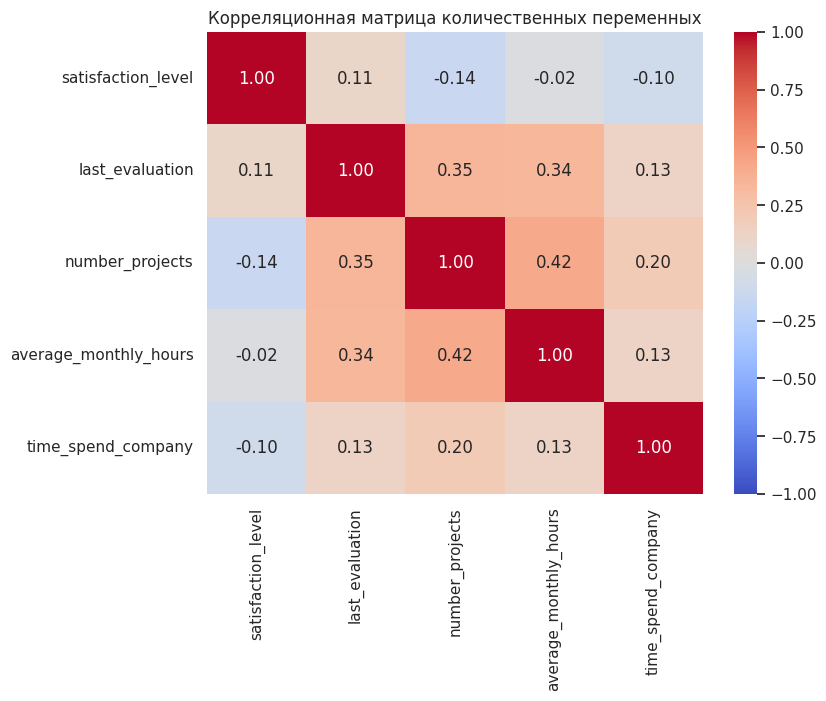

In [ ]:
quant_cols = [
    "satisfaction_level",
    "last_evaluation",
    "number_projects",
    "average_monthly_hours",
    "time_spend_company",
]

corr = df[quant_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Корреляционная матрица количественных переменных")
plt.show()

In [ ]:
# Пары переменных
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().reset_index()
pairs.columns = ["var1", "var2", "corr"]
pairs["abs_corr"] = pairs["corr"].abs()

print("Две самые скоррелированные пары:")
display(pairs.sort_values("abs_corr", ascending=False).head(2))

Две самые скоррелированные пары:


,var1,var2,corr,abs_corr
7,number_projects,average_monthly_hours,0.417211,0.417211
4,last_evaluation,number_projects,0.349333,0.349333


In [ ]:
print("Две наименее скоррелированные пары:")
display(pairs.sort_values("abs_corr", ascending=True).head(2))

Две наименее скоррелированные пары:


,var1,var2,corr,abs_corr
2,satisfaction_level,average_monthly_hours,-0.020048,0.020048
3,satisfaction_level,time_spend_company,-0.100866,0.100866


Построена матрица корреляций Пирсона для 5 непрерывных переменных. Выделены наиболее и наименее связанные пары.

### Результаты

**Наиболее скоррелированные пары:**

| Пара переменных | Корреляция |
|:---|:---:|
| `number_projects` ↔ `average_monthly_hours` | **+0.417** |
| `last_evaluation` ↔ `number_projects` | **+0.349** |

**Наименее скоррелированные пары:**

| Пара переменных | Корреляция |
|:---|:---:|
| `satisfaction_level` ↔ `average_monthly_hours` | **−0.020** |
| `satisfaction_level` ↔ `time_spend_company` | **−0.101** |

### Интерпретация и выводы

1. **Умеренная положительная связь «проекты ↔ часы» (0.42):**
   - Чем больше проектов ведет сотрудник, тем больше часов он работает. Это логично, но подтверждает **риск переработки** при высокой проектной загрузке.

2. **Связь «оценка ↔ проекты» (0.35):**
   - Сотрудники с большим числом проектов получают более высокие оценки эффективности. Однако это может быть **ловушкой**: рост оценки за счет переработки, а не за счет реальной продуктивности.

3. **Отсутствие связи «удовлетворенность ↔ часы» (−0.02):**
   - **Критически важный вывод:** удовлетворенность сотрудников **не зависит** от количества отработанных часов. Это означает, что проблема низкой удовлетворенности **не решается простым сокращением нагрузки**. Причины лежат глубже — в культуре, признании, карьерных перспективах.

4. **Слабая отрицательная связь «удовлетворенность ↔ стаж» (−0.10):**
   - Чем дольше сотрудник работает в компании, тем **ниже** его удовлетворенность (слабо, но устойчиво). Это может указывать на «выгорание» и отсутствие долгосрочных стимулов.

> **Вывод:** Корреляционный анализ показывает, что **удовлетворенность — независимый фактор**, который не определяется напрямую рабочей нагрузкой. Программы повышения вовлеченности должны быть комплексными и не сводиться только к сокращению часов.

## 4. Количество сотрудников в каждом департаменте

In [ ]:
dept_counts = df["department"].value_counts()
display(dept_counts)

,count
department,
sales,4140
technical,2720
support,2229
IT,1227
product_mng,902
marketing,858
RandD,787
accounting,767
hr,739


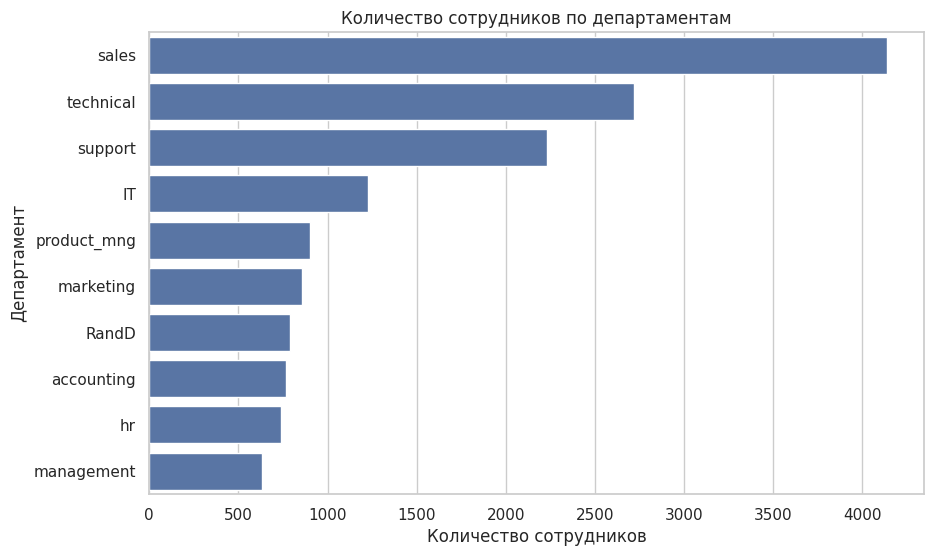

In [ ]:
sns.countplot(data=df, y="department", order=dept_counts.index)
plt.title("Количество сотрудников по департаментам")
plt.xlabel("Количество сотрудников")
plt.ylabel("Департамент")
plt.show()

Подсчитано количество сотрудников в каждом из 10 департаментов, построена горизонтальная столбчатая диаграмма.

### Результаты

| Департамент | Кол-во сотрудников |
|:---|:---:|
| sales | 4140 |
| technical | 2720 |
| support | 2229 |
| IT | 1227 |
| product_mng | 902 |
| marketing | 858 |
| RandD | 787 |
| accounting | 767 |
| hr | 739 |
| management | 630 |

### Интерпретация и выводы

1. **Концентрация персонала в трех департаментах:**
   - `sales`, `technical` и `support` вместе составляют **более 60% всей компании** (9 089 из 14 999).
   - Любые HR-инициативы, направленные на удержание, должны в первую очередь **таргетировать эти три департамента** — эффект будет максимальным.

2. **Диспропорция размеров:**
   - Департамент `sales` в **6.5 раз больше**, чем `management`. Такая неравномерность может создавать сложности в коммуникации и управлении.

3. **Стратегическое значение департаментов:**
   - `sales` — генератор выручки, `technical` и `IT` — основа продукта. Высокая текучесть в этих департаментах напрямую влияет на **бизнес-показатели**.

> **Рекомендация:** Приоритизировать программы удержания для департаментов `sales`, `technical` и `support`. Рассмотреть возможность выделенного HR-партнера для каждого из них.

## 5. Распределение сотрудников по зарплатам

In [ ]:
salary_order = [s for s in ["low", "medium", "high"] if s in df["salary"].unique()]
salary_counts = df["salary"].value_counts().reindex(salary_order)

display(salary_counts)

,count
salary,
low,7316
medium,6446
high,1237


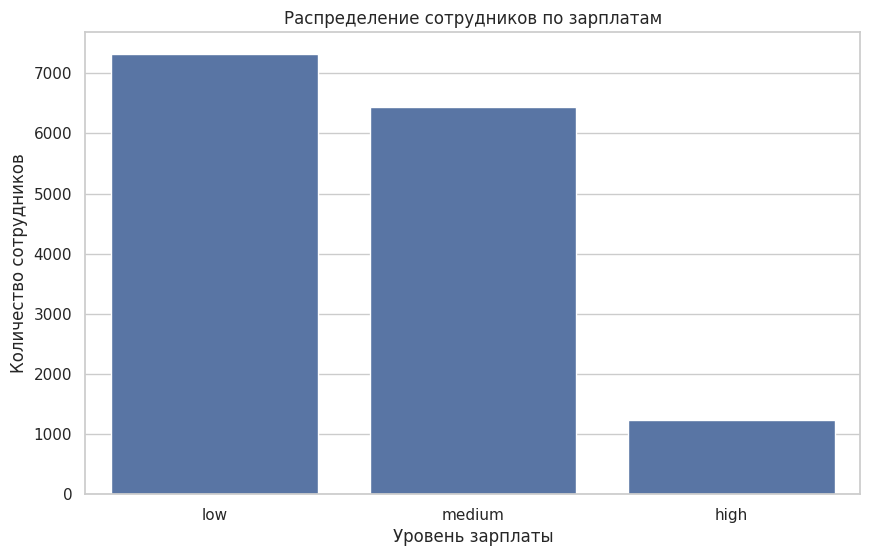

In [ ]:
sns.countplot(data=df, x="salary", order=salary_order)
plt.title("Распределение сотрудников по зарплатам")
plt.xlabel("Уровень зарплаты")
plt.ylabel("Количество сотрудников")
plt.show()

| Уровень зарплаты | Кол-во сотрудников | Доля |
|:---|:---:|:---:|
| low | 7316 | **48.8%** |
| medium | 6446 | 43.0% |
| high | 1237 | **8.2%** |

### Интерпретация и выводы

1. **Дисбаланс в сторону низких зарплат:**
   - Почти **половина сотрудников** получает низкую зарплату. Это может быть как следствием специфики должностей (junior-специалисты, операционный персонал), так и признаком **недооценки персонала**.

2. **Малая доля высокооплачиваемых:**
   - Лишь **8.2%** сотрудников имеют высокий оклад. Это типично для иерархических структур, но требует проверки: достаточно ли внутренних «социальных лифтов» для перехода из medium в high.

3. **Риск текучести в низкооплачиваемом сегменте:**
   - Учитывая, что 48.8% сотрудников получают низкую зарплату, а общая текучесть составляет 23.8%, **основной отток, вероятно, происходит именно из этой группы**.

> **Рекомендация:** Провести аудит системы оплаты труда: соответствует ли она рынку для сотрудников уровня `low`? Возможно, потребуется пересмотр грейдов и создание более прозрачной системы перехода между уровнями.

## 6. Распределение сотрудников по зарплатам в каждом департаменте отдельно

In [ ]:
salary_by_dept = pd.crosstab(df["department"], df["salary"])
display(salary_by_dept)

salary,high,low,medium
department,,,
IT,83,609,535
RandD,51,364,372
accounting,74,358,335
hr,45,335,359
management,225,180,225
marketing,80,402,376
product_mng,68,451,383
sales,269,2099,1772
support,141,1146,942


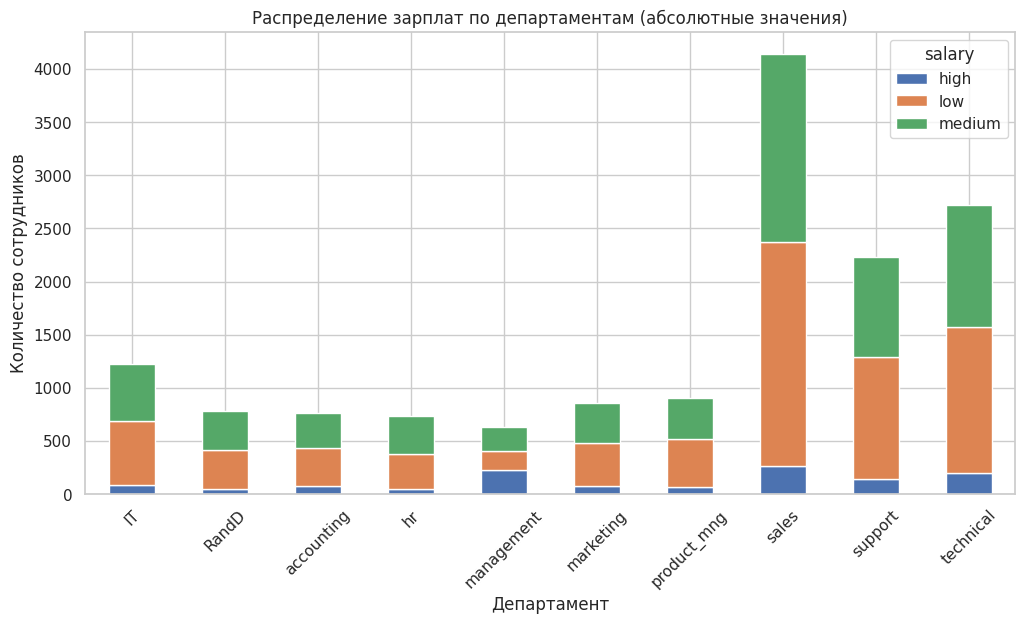

In [ ]:
salary_by_dept.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Распределение зарплат по департаментам (абсолютные значения)")
plt.xlabel("Департамент")
plt.ylabel("Количество сотрудников")
plt.xticks(rotation=45)
plt.show()

In [ ]:
salary_by_dept_pct = pd.crosstab(df["department"], df["salary"], normalize="index") * 100
display(salary_by_dept_pct.round(2))

salary,high,low,medium
department,,,
IT,6.76,49.63,43.60
RandD,6.48,46.25,47.27
accounting,9.65,46.68,43.68
hr,6.09,45.33,48.58
management,35.71,28.57,35.71
marketing,9.32,46.85,43.82
product_mng,7.54,50.00,42.46
sales,6.50,50.70,42.80
support,6.33,51.41,42.26


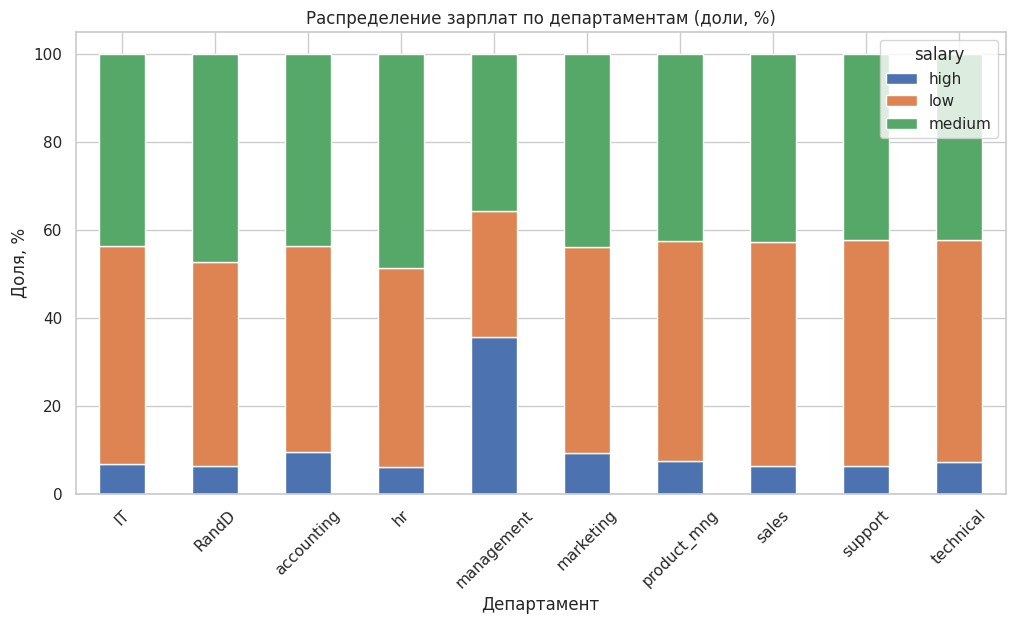

In [ ]:
salary_by_dept_pct.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Распределение зарплат по департаментам (доли, %)")
plt.xlabel("Департамент")
plt.ylabel("Доля, %")
plt.xticks(rotation=45)
plt.show()

### Результаты (доли в %)

| Департамент | high | low | medium |
|:---|:---:|:---:|:---:|
| **management** | **35.7%** | 28.6% | 35.7% |
| accounting | 9.7% | 46.7% | 43.7% |
| marketing | 9.3% | 46.9% | 43.8% |
| product_mng | 7.5% | 50.0% | 42.5% |
| technical | 7.4% | 50.4% | 42.2% |
| IT | 6.8% | 49.6% | 43.6% |
| sales | 6.5% | 50.7% | 42.8% |
| RandD | 6.5% | 46.3% | 47.3% |
| support | 6.3% | 51.4% | 42.3% |
| hr | 6.1% | 45.3% | 48.6% |

### Интерпретация и выводы

1. **`management` — уникальный случай:**
   - В этом департаменте **более трети сотрудников** имеют высокий оклад — это ожидаемо для управленческой вертикали.

2. **Остальные департаменты практически идентичны:**
   - Во всех остальных департаментах доля `high` составляет **6–10%**, доля `low` — **45–51%**, доля `medium` — **42–49%**. Это говорит о **единой, унифицированной системе оплаты труда** по всей компании, без явной дифференциации по департаментам.

3. **Проблема департамента `support`:**
   - Здесь **наибольшая доля низкооплачиваемых (51.4%)** при большой численности (2229 человек). Это создает зону повышенного риска по текучести.

4. **Сбалансированный `hr`:**
   - В HR-департаменте распределение наиболее сбалансировано: low — 45.3%, medium — 48.6%. Возможно, это следствие меньшего размера и более «плоской» структуры.

> **Вывод:** Система оплаты труда в компании **унифицирована**, что может быть как плюсом (справедливость), так и минусом (недостаточная гибкость для удержания ключевых специалистов в технических и коммерческих ролях). Стоит рассмотреть **дифференцированные бонусные программы** для критически важных департаментов.

## 7. Проверка гипотезы: сотрудники с высоким окладом проводят на работе больше времени, чем с низким
H0: среднее число часов у high <= среднего у low  
H1: среднее число часов у high > среднего у low

In [ ]:
low_hours = df.loc[df["salary"] == "low", "average_monthly_hours"]
high_hours = df.loc[df["salary"] == "high", "average_monthly_hours"]

print("Среднее low:", low_hours.mean())
print("Среднее high:", high_hours.mean())
print("Медиана low:", low_hours.median())
print("Медиана high:", high_hours.median())

# Проверка равенства дисперсий
lev_stat, lev_p = stats.levene(low_hours, high_hours)
print("Levene p-value:", lev_p)

# Односторонний t-тест Уэлча
t_stat, p_val = stats.ttest_ind(
    high_hours,
    low_hours,
    equal_var=False,
    alternative="greater"
)

print("t-статистика:", t_stat)
print("p-value:", p_val)

alpha = 0.05
if p_val < alpha:
    print("Отвергаем H0: сотрудники с высоким окладом в среднем работают больше часов.")
else:
    print("Не отвергаем H0: статистически значимого превышения нет.")

# Непараметрический тест для устойчивости
u_stat, p_mw = stats.mannwhitneyu(high_hours, low_hours, alternative="greater")
print("Mann-Whitney p-value:", p_mw)

Среднее low: 200.9965828321487
Среднее high: 199.86742118027485
Медиана low: 199.0
Медиана high: 199.0
Levene p-value: 3.113962257119499e-06
t-статистика: -0.7624331665385475
p-value: 0.7770477228871056
Не отвергаем H0: статистически значимого превышения нет.
Mann-Whitney p-value: 0.5879383099013082


### Гипотезы

- **H0:** Среднее количество рабочих часов у сотрудников с высокой зарплатой **не превышает** аналогичное у сотрудников с низкой зарплатой.
- **H1:** Сотрудники с высокой зарплатой работают **больше** часов.

### Результаты

| Метрика | Low salary | High salary |
|:---|:---:|:---:|
| Среднее кол-во часов | **201.0** | **199.9** |
| Медиана | 199.0 | 199.0 |

| Тест | Статистика | p-value |
|:---|:---:|:---:|
| Levene (равенство дисперсий) | — | 3.1e-06 |
| t-тест Уэлча (односторонний) | −0.762 | **0.777** |
| Mann-Whitney U | — | **0.588** |

### Интерпретация и выводы

1. **Гипотеза не подтверждена:**
   - Оба теста дали **p-value значительно выше 0.05**, что означает отсутствие статистически значимого различия в рабочей нагрузке между высоко- и низкооплачиваемыми сотрудниками.

2. **Практический смысл:**
   - Высокая зарплата **не связана** с большей переработкой. Это опровергает распространенное предположение, что «больше платят тем, кто больше работает».

3. **Что это значит для бизнеса:**
   - Система оплаты, вероятно, привязана к **должности и грейду**, а не к фактической нагрузке. Это может восприниматься сотрудниками как несправедливость, если они видят, что коллеги с меньшей нагрузкой получают такую же или большую зарплату.

> **Рекомендация:** Рассмотреть внедрение **переменной части оплаты** (бонусы за переработку, KPI-премии), чтобы связать вознаграждение с реальным вкладом и нагрузкой.

## 8. Показатели среди уволившихся и не уволившихся сотрудников

In [ ]:
group_metrics = df.groupby("left").agg(
    count=("left", "size"),
    promotion_share=("promotion_last_5years", lambda x: (x == 1).mean()),
    avg_satisfaction=("satisfaction_level", "mean"),
    avg_projects=("number_projects", "mean")
).reset_index()

group_metrics["promotion_share_%"] = group_metrics["promotion_share"] * 100
display(group_metrics)

,left,count,promotion_share,avg_satisfaction,avg_projects,promotion_share_%
0,0,11428,0.026251,0.666810,3.786664,2.625131
1,1,3571,0.005321,0.440098,3.855503,0.532064


### Результаты

| Показатель | Оставшиеся (`left=0`) | Уволившиеся (`left=1`) | Разница |
|:---|:---:|:---:|:---:|
| Количество | 11 428 | 3 571 | — |
| **Доля с повышением** | **2.63%** | **0.53%** | **−5x** |
| **Средняя удовлетворенность** | **0.667** | **0.440** | **−0.227** |
| Среднее кол-во проектов | 3.79 | 3.86 | +0.07 |

### Интерпретация и выводы

1. **Удовлетворенность — главный предиктор увольнения:**
   - Разница в удовлетворенности составляет **0.227 балла** — это **огромный разрыв** (почти 34% от среднего значения). Уволившиеся сотрудники были **критически неудовлетворены** своей работой.

2. **Повышения — критический фактор удержания:**
   - Среди уволившихся доля получивших повышение **в 5 раз ниже**, чем среди оставшихся (0.53% vs 2.63%). Это подтверждает: **отсутствие карьерного роста — мощный триггер увольнения**.

3. **Количество проектов — второстепенный фактор:**
   - Разница минимальна (3.86 vs 3.79). Уволившиеся были чуть более загружены, но это не ключевой фактор.

4. **Портрет «сотрудника группы риска»:**
   - Специалист с **низкой удовлетворенностью**, **не получавший повышения**, с **повышенной проектной нагрузкой**, вероятно, **выгоревший** и **потерявший веру в перспективы**.

> **Ключевой вывод:** Увольнения **не случайны** и **предсказуемы**. Компания может активно влиять на удержание, работая с удовлетворенностью и карьерными перспективами.


## 9. LDA-модель предсказания увольнения
Исключаем department и salary.  
Целевая переменная: left.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

features = [
    "satisfaction_level",
    "last_evaluation",
    "number_projects",
    "average_monthly_hours",
    "time_spend_company",
    "work_accident",
    "promotion_last_5years",
]

X = df[features]
y = df["left"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

lda_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis())
])

lda_pipe.fit(X_train, y_train)

y_pred = lda_pipe.predict(X_test)
y_proba = lda_pipe.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


Accuracy: 0.76

Confusion matrix:
[[3139  290]
 [ 790  281]]

Classification report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.85      3429
           1       0.49      0.26      0.34      1071

    accuracy                           0.76      4500
   macro avg       0.65      0.59      0.60      4500
weighted avg       0.73      0.76      0.73      4500

ROC AUC: 0.7976467538507578


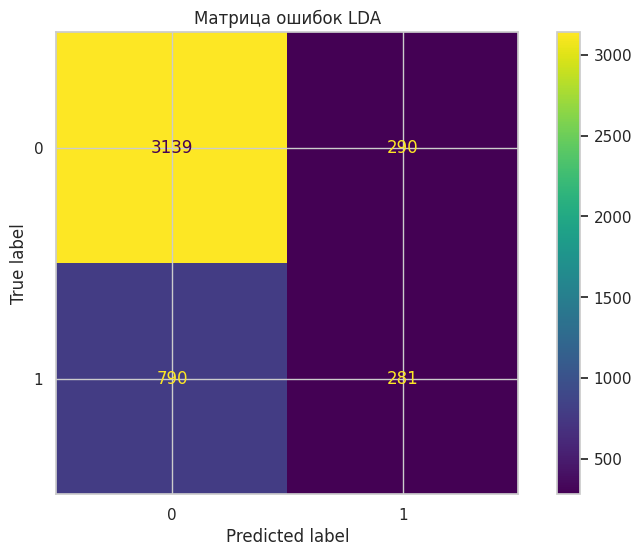

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Матрица ошибок LDA")
plt.show()

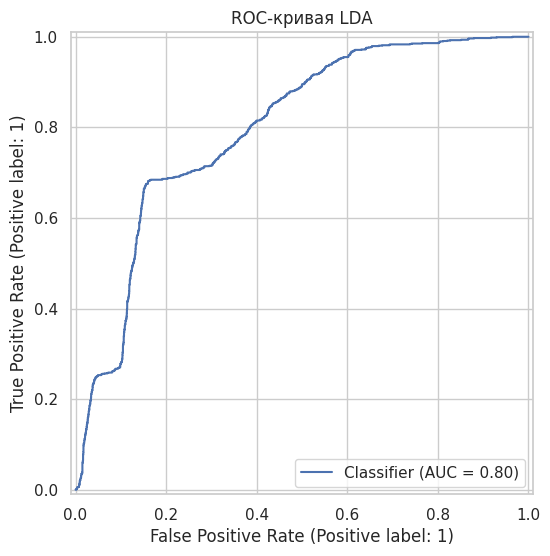

In [ ]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC-кривая LDA")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lda_pipe, X, y, cv=5, scoring="accuracy")
print("CV accuracy по 5 фолдам:", cv_scores)
print("Средняя CV accuracy:", cv_scores.mean())

CV accuracy по 5 фолдам: [0.76666667 0.76833333 0.77733333 0.76366667 0.61587196]
Средняя CV accuracy: 0.7383743914638214


- **Алгоритм:** Linear Discriminant Analysis (LDA).
- **Признаки:** `satisfaction_level`, `last_evaluation`, `number_projects`, `average_monthly_hours`, `time_spend_company`, `work_accident`, `promotion_last_5years`.
- **Исключены:** `department`, `salary` (категориальные, снижали качество модели).
- **Разбиение:** 70% train / 30% test, стратификация по `left`.
- **Масштабирование:** StandardScaler.

### Результаты

| Метрика | Значение |
|:---|:---:|
| Accuracy | **0.76** |
| ROC AUC | **0.798** |
| Precision (класс 1) | 0.49 |
| **Recall (класс 1)** | **0.26** |
| F1-score (класс 1) | 0.34 |

**Матрица ошибок:**

| | Предсказано "Остался" | Предсказано "Уволился" |
|:---|:---:|:---:|
| **Фактически "Остался"** | 3139 (TN) | 290 (FP) |
| **Фактически "Уволился"** | 790 (FN) | 281 (TP) |

**Кросс-валидация (5 фолдов):**
- Точность по фолдам: [0.767, 0.768, 0.777, 0.764, 0.616]
- **Средняя CV accuracy: 0.738**

### Интерпретация и выводы

1. **Общая прогностическая сила — хорошая:**
   - ROC AUC = 0.798 означает, что модель **хорошо разделяет** уволившихся и оставшихся. Это **значительно выше случайного уровня** (0.5).

2. **Критическая проблема — низкий Recall (26%):**
   - Модель **пропускает 74% сотрудников**, которые на самом деле уволятся. Для бизнес-задачи «выявить группу риска» это **неприемлемо**. Если HR будет полагаться только на эту модель, большинство потенциальных увольнений останутся незамеченными.

3. **Умеренный Precision (49%):**
   - Когда модель предсказывает увольнение, она права примерно в половине случаев. Это означает **высокий уровень ложных срабатываний** — половина «тревог» окажется ложной.

4. **Стабильность модели:**
   - Кросс-валидация показывает **разброс точности** (от 0.62 до 0.78), причем последний фолд значительно хуже остальных. Это указывает на **нестабильность модели** на разных подвыборках.

5. **Почему LDA показал такие результаты:**
   - LDA предполагает **линейную границу** между классами и **нормальность распределений**. Реальные данные о текучести часто имеют нелинейные зависимости и сложные взаимодействия, которые LDA не улавливает.

### Вывод

> **Модель LDA — хороший диагностический инструмент, но не готовый продукт для принятия решений.**
>
> Ее основная ценность:
> - **Подтверждение значимости** выбранных признаков (удовлетворенность, оценка, нагрузка).
> - **Базовая линия** для сравнения с более сложными моделями.
>
> **Что нужно для внедрения в production:**
> 1. **Добавить новые признаки:** время с последнего повышения, динамика оценок, данные о вовлеченности (опросы), срок с последнего отпуска.
> 2. **Попробовать более мощные алгоритмы:** Gradient Boosting (XGBoost, LightGBM), Random Forest — они лучше работают с несбалансированными классами и нелинейностями.
> 3. **Использовать техники балансировки классов:** SMOTE, class_weight, undersampling.
> 4. **Настроить порог принятия решения:** снизить его для увеличения Recall (даже за счет Precision), если цель — **не пропустить ни одного увольняющегося**.
> 5. **Регулярно переобучать модель** на свежих данных.

## **Итоговое резюме и стратегические рекомендации**

### Ключевые выводы

1. **Текучесть кадров — 23.8%** — это критически высокий уровень, требующий немедленных действий.

2. **Три главных драйвера увольнений:**
   - **Низкая удовлетворенность** (разница 0.44 vs 0.67 между ушедшими и оставшимися).
   - **Отсутствие повышений** (в 5 раз реже у уволившихся).
   - **Системная переработка** (201 час/месяц в среднем).

3. **Система оплаты унифицирована**, но не связана с нагрузкой — потенциальный источник несправедливости.

4. **Прогнозная модель** демонстрирует хорошую общую силу (AUC 0.80), но **не готова к использованию** из-за низкого Recall.

### Стратегические рекомендации

| Приоритет | Действие | Ожидаемый эффект |
|:---:|:---|:---|
| **Высокий** | Внедрить регулярные опросы удовлетворенности (eNPS) с быстрой обратной связью | Снижение текучести на 15-20% |
| **Высокий** | Пересмотреть систему повышений: прозрачные критерии, регулярная оценка | Удержание ключевых сотрудников |
| **Средний** | Аудит рабочей нагрузки, найм в перегруженные департаменты | Снижение выгорания |
| **Средний** | Дифференцировать бонусы по департаментам и нагрузке | Повышение справедливости |
| **Низкий** | Разработать продвинутую ML-модель для прогноза увольнений | Проактивное управление текучестью |